In [12]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [13]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/AI-ML-Portfolio/Netflix-Content-Strategy-Analysis/data/netflix_titles.csv"
)

df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [14]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [15]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_theme()

pd.set_option("display.max_columns", None)

In [17]:
df.shape
df.columns
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


In [18]:
df.isnull().sum().sort_values(ascending=False)

,0
director,2634
country,831
cast,825
date_added,10
rating,4
duration,3
show_id,0
type,0
title,0
release_year,0


In [26]:
df["director"] = df["director"].fillna("Unknown")
df["country"] = df["country"].fillna("Unknown")
df["cast"] = df["cast"].fillna("Unknown")

In [24]:
df = df.dropna(subset=["date_added"])
df = df.dropna(subset=["duration"])


In [23]:
df[df["rating"].isnull()]

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
5989,s5990,Movie,13TH: A Conversation with Oprah Winfrey & Ava ...,Unknown,"Oprah Winfrey, Ava DuVernay",Unknown,"January 26, 2017",2017,NaN,37 min,Movies,Oprah Winfrey sits down with director Ava DuVe...
6827,s6828,TV Show,Gargantia on the Verdurous Planet,Unknown,"Kaito Ishikawa, Hisako Kanemoto, Ai Kayano, Ka...",Japan,"December 1, 2016",2013,NaN,1 Season,"Anime Series, International TV Shows","After falling through a wormhole, a space-dwel..."
7312,s7313,TV Show,Little Lunch,Unknown,"Flynn Curry, Olivia Deeble, Madison Lu, Oisín ...",Australia,"February 1, 2018",2015,NaN,1 Season,"Kids' TV, TV Comedies","Adopting a child's perspective, this show take..."
7537,s7538,Movie,My Honor Was Loyalty,Alessandro Pepe,"Leone Frisa, Paolo Vaccarino, Francesco Miglio...",Italy,"March 1, 2017",2015,NaN,115 min,Dramas,"Amid the chaos and horror of World War II, a c..."


In [25]:
df = df.dropna(subset=["rating"])

In [27]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,0
cast,0
country,0
date_added,0
release_year,0
rating,0
duration,0


In [31]:
for x in df["date_added"].dropna().sample(20):
    print(repr(x))

'June 1, 2020'
'November 2, 2019'
'June 15, 2021'
'March 8, 2019'
'August 1, 2019'
'August 31, 2020'
'August 13, 2020'
'June 28, 2019'
'October 1, 2019'
'January 29, 2021'
'May 12, 2020'
'May 1, 2021'
'November 30, 2019'
'March 21, 2019'
'June 20, 2019'
'May 30, 2017'
'March 24, 2021'
'July 1, 2019'
'December 4, 2020'
'August 1, 2020'


In [32]:
bad_dates = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

df[bad_dates.isna()][["title", "date_added"]]

,title,date_added
6079,Abnormal Summit,"August 4, 2017"
6177,忍者ハットリくん,"December 23, 2018"
6213,Bad Education,"December 15, 2018"
6279,Being Mary Jane: The Series,"July 1, 2017"
6304,"Big Dreams, Small Spaces","July 26, 2019"
...,...,...
8539,The Tudors,"January 8, 2018"
8557,The West Wing,"December 25, 2015"
8684,Vroomiz,"August 1, 2017"
8712,Weird Wonders of the World,"March 31, 2017"


In [33]:
df["date_added"] = df["date_added"].str.strip()

converted = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

df[converted.isna()][["title", "date_added"]]

,title,date_added


In [34]:
df["date_added"] = df["date_added"].str.strip()

df["date_added"] = pd.to_datetime(
    df["date_added"],
    format="mixed",
    errors="coerce"
)

In [35]:
df["date_added"].isna().sum()

np.int64(0)

In [37]:
df["year_added"] = df["date_added"].dt.year

df["month_added"] = df["date_added"].dt.month

df["month_name"] = df["date_added"].dt.month_name()

In [38]:
df[["date_added","year_added","month_name"]].head()

,date_added,year_added,month_name
0,2021-09-25,2021,September
1,2021-09-24,2021,September
2,2021-09-24,2021,September
3,2021-09-24,2021,September
4,2021-09-24,2021,September


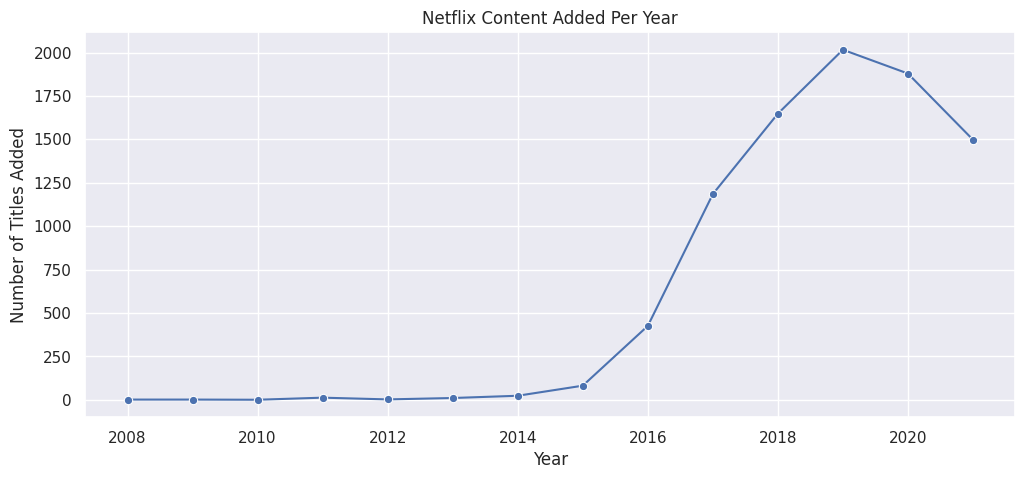

In [39]:
content_growth = (
    df["year_added"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=content_growth.index,
    y=content_growth.values,
    marker="o"
)

plt.title("Netflix Content Added Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.show()

1. after 2016 we can see rapid Growth
2. 2019 we can see the highest content addition(~2000)
3. there was a decline after 2020,


In [40]:
df["type"].value_counts()

,count
type,
Movie,6126
TV Show,2664


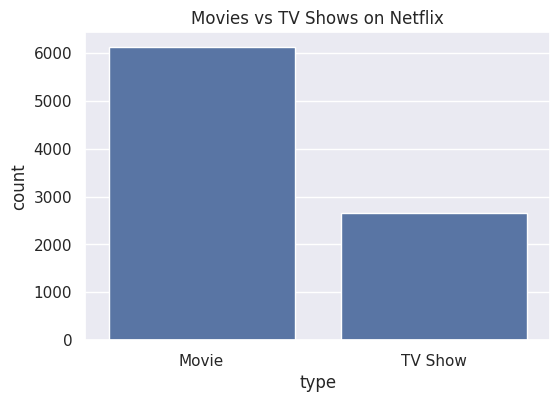

In [41]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="type"
)

plt.title("Movies vs TV Shows on Netflix")

plt.show()

In [42]:
df["rating"].value_counts()

,count
rating,
TV-MA,3205
TV-14,2157
TV-PG,861
R,799
PG-13,490
TV-Y7,333
TV-Y,306
PG,287
TV-G,220


In [43]:
def audience_group(rating):

    kids = ["TV-Y","TV-Y7","TV-Y7-FV","TV-G","G"]

    teen = ["TV-PG","TV-14","PG","PG-13"]

    adult = ["TV-MA","R","NC-17","NR","UR"]

    if rating in kids:
        return "Kids"

    elif rating in teen:
        return "Teen"

    elif rating in adult:
        return "Adult"

    else:
        return "Unknown"

df["audience_type"] = df["rating"].apply(audience_group)

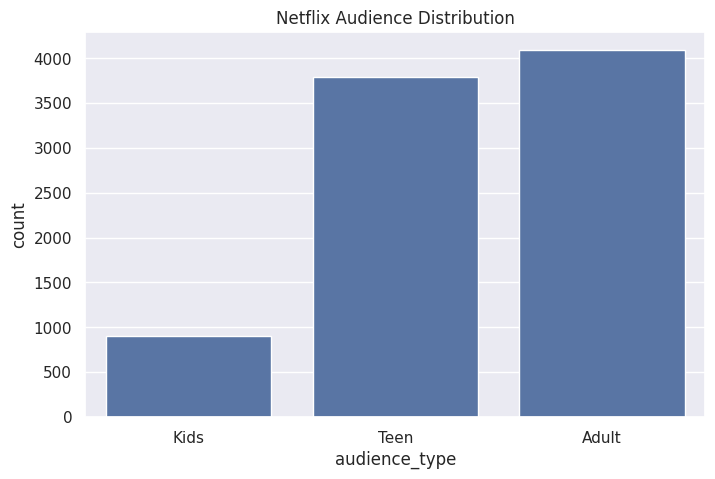

In [72]:
df["audience_type"].value_counts()
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="audience_type",
    order=["Kids","Teen","Adult"]
)

plt.title("Netflix Audience Distribution")

plt.show()

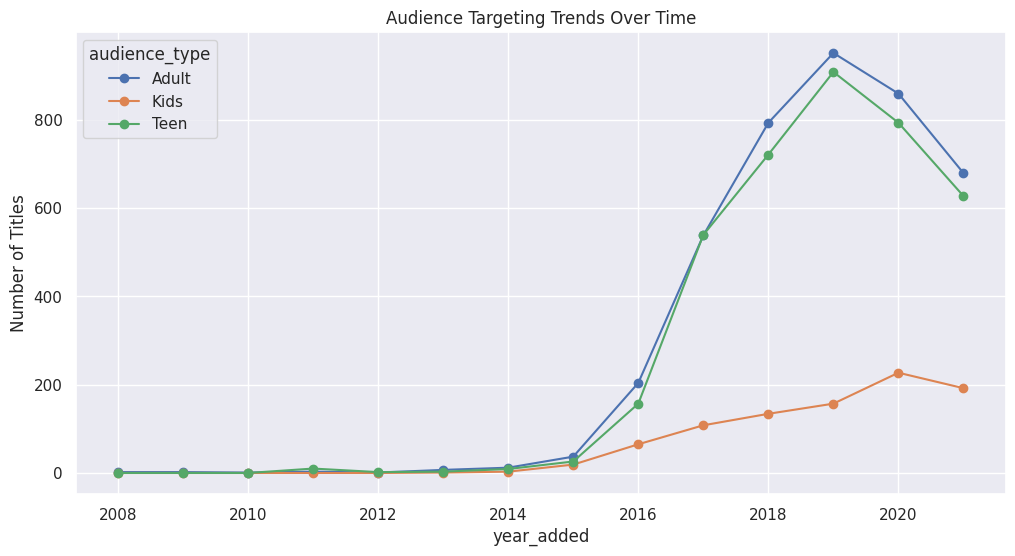

In [45]:
audience_year = pd.crosstab(
    df["year_added"],
    df["audience_type"]
)

audience_year.plot(
    figsize=(12,6),
    marker="o"
)

plt.title("Audience Targeting Trends Over Time")

plt.ylabel("Number of Titles")

plt.show()

In [46]:
df["country"].value_counts().head(20)

,count
country,
United States,2809
India,972
Unknown,829
United Kingdom,418
Japan,243
South Korea,199
Canada,181
Spain,145
France,124


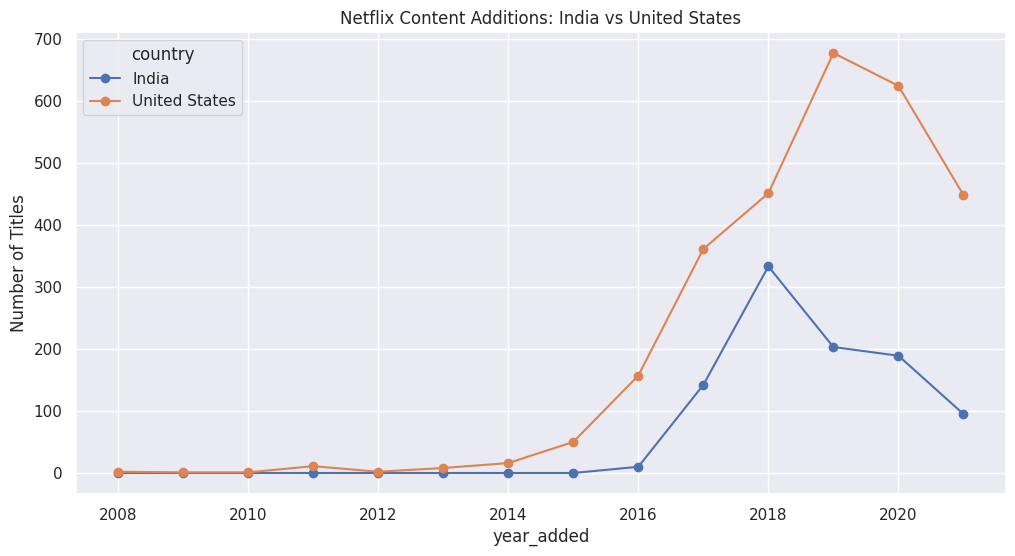

In [47]:
country_year = (
    df[df["country"].isin(["United States", "India"])]
    .groupby(["year_added", "country"])
    .size()
    .unstack(fill_value=0)
)

country_year.plot(
    figsize=(12,6),
    marker="o"
)

plt.title("Netflix Content Additions: India vs United States")
plt.ylabel("Number of Titles")
plt.show()

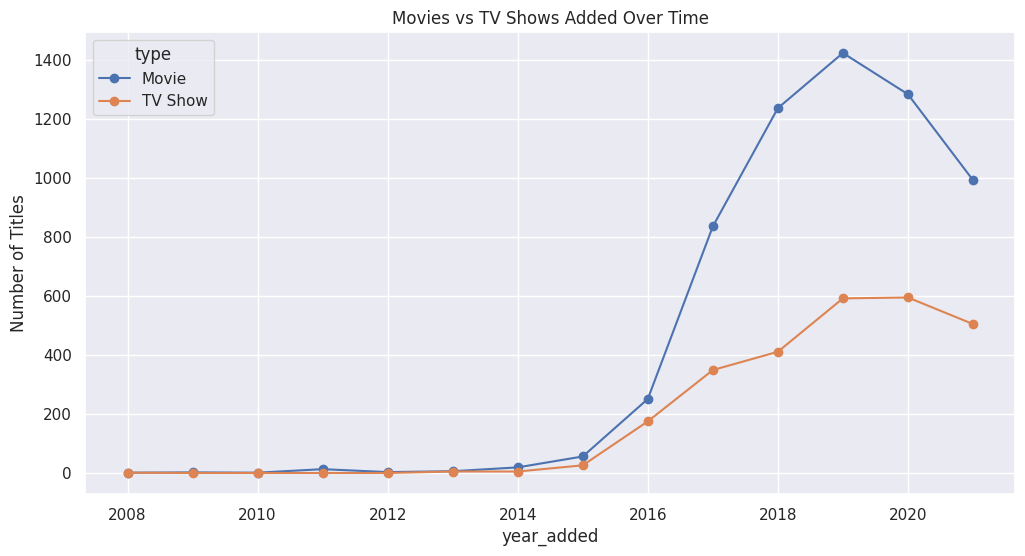

In [48]:
movies_tv = pd.crosstab(
    df["year_added"],
    df["type"]
)

movies_tv.plot(
    figsize=(12,6),
    marker="o"
)

plt.title("Movies vs TV Shows Added Over Time")
plt.ylabel("Number of Titles")
plt.show()

In [49]:
df["listed_in"].head(10)

,listed_in
0,Documentaries
1,"International TV Shows, TV Dramas, TV Mysteries"
2,"Crime TV Shows, International TV Shows, TV Act..."
3,"Docuseries, Reality TV"
4,"International TV Shows, Romantic TV Shows, TV ..."
5,"TV Dramas, TV Horror, TV Mysteries"
6,Children & Family Movies
7,"Dramas, Independent Movies, International Movies"
8,"British TV Shows, Reality TV"
9,"Comedies, Dramas"


In [51]:
genre_df = df.copy()

genre_df["listed_in"] = genre_df["listed_in"].str.split(", ")

genre_df = genre_df.explode("listed_in")

In [52]:
genre_df.head(10)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description,year_added,month_added,month_name,audience_type
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",2021,9,September,Teen
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t...",2021,9,September,Adult
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t...",2021,9,September,Adult
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t...",2021,9,September,Adult
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,Crime TV Shows,To protect his family from a powerful drug lor...,2021,9,September,Adult
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,International TV Shows,To protect his family from a powerful drug lor...,2021,9,September,Adult
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,TV Action & Adventure,To protect his family from a powerful drug lor...,2021,9,September,Adult
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,Docuseries,"Feuds, flirtations and toilet talk go down amo...",2021,9,September,Adult
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,Reality TV,"Feuds, flirtations and toilet talk go down amo...",2021,9,September,Adult
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,International TV Shows,In a city of coaching centers known to train I...,2021,9,September,Adult


In [53]:
top_genres = (
    genre_df["listed_in"]
    .value_counts()
    .head(15)
)

top_genres

,count
listed_in,
International Movies,2752
Dramas,2426
Comedies,1674
International TV Shows,1349
Documentaries,869
Action & Adventure,859
TV Dramas,762
Independent Movies,756
Children & Family Movies,641


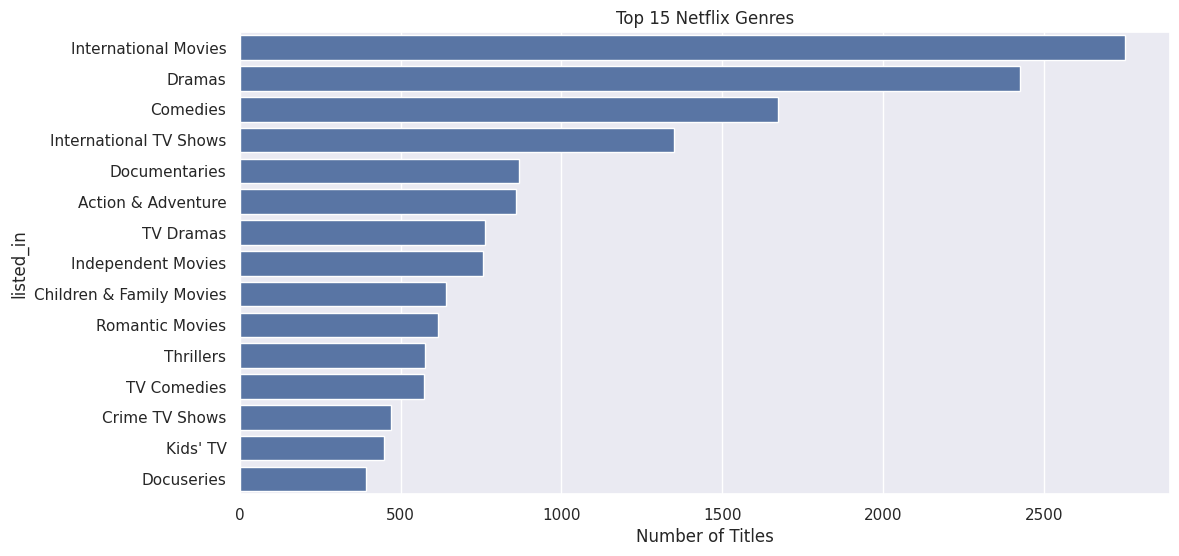

In [54]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_genres.values,
    y=top_genres.index
)

plt.title("Top 15 Netflix Genres")

plt.xlabel("Number of Titles")

plt.show()

In [55]:
india_us = genre_df[
    genre_df["country"].isin(["India","United States"])
]


In [56]:
india_genres = (
    india_us[india_us["country"]=="India"]
    ["listed_in"]
    .value_counts()
    .head(10)
)

india_genres

,count
listed_in,
International Movies,817
Dramas,620
Comedies,308
Independent Movies,150
Action & Adventure,127
Romantic Movies,118
Music & Musicals,88
Thrillers,88
International TV Shows,65


In [57]:
us_genres = (
    india_us[india_us["country"]=="United States"]
    ["listed_in"]
    .value_counts()
    .head(10)
)

us_genres

,count
listed_in,
Dramas,591
Comedies,524
Documentaries,411
Independent Movies,302
Children & Family Movies,272
Action & Adventure,249
TV Comedies,229
Stand-Up Comedy,215
Thrillers,193


In [60]:
exclude = [
    "International Movies",
    "International TV Shows"
]

genre_clean = genre_df[
    ~genre_df["listed_in"].isin(exclude)
]

In [62]:
india_us_clean = genre_clean[
    genre_clean["country"].isin(["India", "United States"])
]

In [63]:
india_genres = (
    india_us_clean[india_us_clean["country"]=="India"]
    ["listed_in"]
    .value_counts()
    .head(10)
)

india_genres

,count
listed_in,
Dramas,620
Comedies,308
Independent Movies,150
Action & Adventure,127
Romantic Movies,118
Music & Musicals,88
Thrillers,88
Horror Movies,32
TV Dramas,27


In [64]:
us_genres = (
    india_us_clean[india_us_clean["country"]=="United States"]
    ["listed_in"]
    .value_counts()
    .head(10)
)

us_genres

,count
listed_in,
Dramas,591
Comedies,524
Documentaries,411
Independent Movies,302
Children & Family Movies,272
Action & Adventure,249
TV Comedies,229
Stand-Up Comedy,215
Thrillers,193


In [69]:
india_pct = (
    india_genres / india_genres.sum()
) * 100

india_pct

,count
listed_in,
Dramas,39.141414
Comedies,19.444444
Independent Movies,9.469697
Action & Adventure,8.017677
Romantic Movies,7.449495
Music & Musicals,5.555556
Thrillers,5.555556
Horror Movies,2.020202
TV Dramas,1.704545


In [70]:
us_pct = (
    us_genres / us_genres.sum()
) * 100
us_pct

,count
listed_in,
Dramas,18.614173
Comedies,16.503937
Documentaries,12.944882
Independent Movies,9.511811
Children & Family Movies,8.566929
Action & Adventure,7.842520
TV Comedies,7.212598
Stand-Up Comedy,6.771654
Thrillers,6.078740
